In [1]:
import phoenix as px
from phoenix.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor

# 1. Запускаем сервер Phoenix
session = px.launch_app()

# 2. Регистрируем провайдер трассировки (OpenTelemetry)
# Он будет перехватывать данные и отправлять их в локальный Phoenix
tracer_provider = register()

# 3. Включаем "прослушку" именно для LangChain
LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

print(f"Phoenix готов! Дашборд тут: {session.url}")

/Users/artemzmailov/Desktop/kitoboy-PII/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/Users/artemzmailov/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11/contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_cumulative_llm_token_count_total
  next(self.gen)
/Users/artemzmailov/.local/share/uv/python/cpython-3.11.15-macos-aarch64-none/lib/python3.11/contextlib.py:144: SAWarning: Skipped unsupported reflection of expression-based index ix_latency
  next(self.gen)
E0501 21:07:24.378069 6947435 add_port.cc:83] Failed to add port to server: No address added out of total 1 resolved for '[::]:4317'
ERROR:    Traceback (most recent call last):
  File "/Users/artemzmailov/Desktop/kitoboy-PII/.venv/lib/python3.11/site-packages/starlette/routing.

🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: default
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  ⚠️ WARNING: It is strongly advised to use a BatchSpanProcessor in production environments.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



AttributeError: 'NoneType' object has no attribute 'url'

In [2]:
import os
from dotenv import load_dotenv

load_dotenv()

api_key = os.getenv("MISTRAL_API_KEY")
print(api_key)

Lld8KeTo2clg7lurqzk9G0XZlCuGBdhx


In [3]:
import yaml

with open("../../configs/prompts.yaml", "r", encoding="utf-8") as f:
    PROMPTS_CONFIG = yaml.safe_load(f)


In [4]:
from langchain_core.rate_limiters import InMemoryRateLimiter
from langchain_mistralai import ChatMistralAI

rate_limiter = InMemoryRateLimiter(
    requests_per_second=0.3,   
    check_every_n_seconds=0.1,
    max_bucket_size=1,
)
from langchain_mistralai import ChatMistralAI

llm = ChatMistralAI(model="mistral-medium-latest", #mistral-small-2506
                    temperature=0.7,
                    timeout = 60,
                    rate_limiter=rate_limiter,
                    max_concurrent_requests=1,
                    max_retries=3)

In [5]:
import random
from pathlib import Path
import json
from typing import List, Dict, Set, TypedDict, Annotated, Optional
import operator

class FinalResult(TypedDict):
    text: str
    used_entities: List[Dict[str, str]]
    source_fragment: str
    
class OrchestratorState(TypedDict):
    random_seed: Optional[int]
    pool_dir: str      
    total_n: Optional[int]                 # Желаемое общее кол-во типов сущностей
    entity_config: Dict[str, int]          # Словарь {"название": количество}
    default_m: int                         # Сколько генерить, если в словаре нет ключа
    output_path: Optional[str]             # Если указан, каждый готовый текст сразу пишется в JSONL
    
    # Внутренние поля
    inventory: Dict[str, Set[str]]
    # Сюда синтезатор кладет результат одной итерации для проверки
    current_task_result: Optional[FinalResult]
    
    # Сюда попадают только проверенные пары {text, entities}
    final_results: Annotated[List[FinalResult], operator.add]
    
    consecutive_errors: int
    max_consecutive_errors: int

TEXT_FRAGMENTS_POOL: list[str] = []


# --- УЗЛЫ ---


def _load_pool_values(pool_dir: Path, entity_key: str) -> list[str]:
    fp = pool_dir / f"{entity_key}.json"
    if not fp.exists():
        raise FileNotFoundError(f"Pool file not found: {fp}")
    data = json.loads(fp.read_text(encoding="utf-8"))
    if not isinstance(data, list):
        raise ValueError(f"{fp} must contain JSON array")
    return [x.strip() for x in data if isinstance(x, str) and x.strip()]


def prepare_inventory_node(state: OrchestratorState):
    # 1) сид
    seed = state.get("random_seed")
    if seed is not None:
        random.seed(seed)

    pool_dir = Path(state.get("pool_dir", "../../data/entities_pool"))
    if not pool_dir.exists():
        raise FileNotFoundError(f"Pool directory not found: {pool_dir}")

    # 2) доступные сущности = имена json-файлов в пуле
    available_entities = sorted(p.stem for p in pool_dir.glob("*.json"))
    if not available_entities:
        raise ValueError(f"No pool files found in: {pool_dir}")

    print(f"Доступно типов из пула: {available_entities}")
    max_entities = len(available_entities)

    # 3) базовые tasks из входа
    tasks = state["entity_config"].copy()
    excluded = {k for k, v in tasks.items() if v <= 0}
    tasks = {k: v for k, v in tasks.items() if v > 0}

    # Отфильтровать всё, чего нет в пуле
    tasks = {k: v for k, v in tasks.items() if k in available_entities}

    target_n = state.get("total_n") or len(tasks)
    if target_n > max_entities:
        print(f"Внимание: total_n={target_n}, но в пуле только {max_entities}. Снижаем до лимита.")
        target_n = max_entities

    # 4) добор случайных сущностей до target_n
    if len(tasks) < target_n:
        remaining = [e for e in available_entities if e not in tasks and e not in excluded]
        needed = min(target_n - len(tasks), len(remaining))
        for ent in random.sample(remaining, needed):
            tasks[ent] = state["default_m"]

    print(f"(^_^) Итоговый план генерации: {tasks}")

    # 5) сразу формируем inventory
    inventory = {}
    for entity, need in tasks.items():
        values = _load_pool_values(pool_dir, entity)
        if len(values) < need:
            raise ValueError(f"Not enough values for {entity}: need={need}, have={len(values)}")
        picked = random.sample(values, need)
        inventory[entity] = set(picked)

    print(f"(OoO) Инвентарь подготовлен: {len(inventory)} категорий")

    return {"inventory": inventory}


In [6]:
from pydantic import BaseModel, Field
from typing import List

class EntityItem(BaseModel):
    key: str = Field(description="Категория сущности из inventory, например PASSPORT_RF")
    value: str = Field(description="Конкретная строка из списка inventory[key], без изменений")
    insertion_hint: str = Field(description="Подсказка, как подвести текст к этому значению, чтобы оно не висело в воздухе")

class SynthesisResponse(BaseModel):
    text: str = Field(description="Текст поста", default='')
    logic_of_entry: str = Field(description="Общая идея вставки выбранных данных", default='')
    entities: List[EntityItem] = Field(
        description="Список вставленных сущностей и их значений в текст",
        default_factory=list
    )

In [7]:
from langchain_core.tools import tool
from langchain_core.runnables.config import RunnableConfig
from typing import List, Dict

@tool
def plan_insertion(logic_of_entry: str, chosen_data: List[EntityItem], config: RunnableConfig):
    """
    ПЕРВЫЙ ШАГ: Пойми, зачем человеку в этом тексте вообще называть свои данные. 
    logic_of_entry: Общая идея вставки: что должно произойти в тексте, чтобы выбранные данные прозвучали естественно.
    Если данных несколько, придумай одну общую ситуацию, которая связывает их между собой.

    chosen_data: Список объектов EntityItem(key="КАТЕГОРИЯ", value="ЗНАЧЕНИЕ", insertion_hint="ПОДСКАЗКА ДЛЯ ВСТАВКИ")
                 key - это строго название категории данных из ДОСТУПНОГО ПУЛА.
                 value - это конкретная строка из inventory[key], без изменений.
                 insertion_hint - Подсказка для одной сущности: как именно подвести текст к этому значению, чтобы оно не висело в воздухе.
    Ты должен добавить в chosen_data только те ЗНАЧЕНИЯ и их КАТЕГОРИИ, которые впишутся в этот 'повод' без фальши и будут вставлены в текст.
    ВАЖНО: 
    1. Ты получаешь на вход словарь 'inventory', где КЛЮЧ — это категория данных, а ЗНАЧЕНИЕ — список доступных строк (конкретных примеров этой категории).
    2. Выбирай только те значения, которые реально присутствуют в предоставленном inventory.
    3. В поле 'value' передавай строку из списка целиком, без изменений, она является цельным примером.
    Пример: если в inventory есть {"PASSPORT_RF": ["4511 123456"]}, твой chosen_data должен быть:
    [{
    "key": "PASSPORT_RF",
    "value": "4511 123456",
    "insertion_hint": "автор упоминает оформление документов и поэтому приводит паспортные данные"
    }]
    """
    local_storage = config["configurable"].get("synthesis_storage")
    
    if local_storage:
        local_storage.entities = chosen_data
        local_storage.logic_of_entry = logic_of_entry
    
    print(f"\n[PLAN] Логика: {logic_of_entry}")
    print(f"[PLAN] В память занесено (значения): {chosen_data}")
    return f"Понял, вписываем через: {logic_of_entry}. Берем категории и значения: {chosen_data}"

@tool
def write_draft(text: str, config: RunnableConfig):
    """
    ВТОРОЙ ШАГ: Напиши само сообщение. 
    Текст должен остаться живым: сбивчивым, эмоциональным или деловым — смотря какой оригинал. 
    
    КРИТИЧЕСКИ ВАЖНО: 
    1. Используй ТОЛЬКО те конкретные значения данных, которые ты указал в "value" в plan_insertion (chosen_data). 
    2. Не вставляй лишние данные из пула, если их не было в плане.
    3. Данные ОБЯЗАТЕЛЬНО оборачивай в ПАРНЫЕ теги: <ENTITY_KEY>данные</ENTITY_KEY>, где ENTITY_KEY - это название Категории в plan_insertion (chosen_data).
    4. Переход к данным должен быть семантически связан с соседними предложениями и не должен выглядеть как универсальная вставка-шаблон или звучать искусственно.
    5. Для каждой сущности опирайся на её insertion_hint из chosen_data: подведи текст к значению так, чтобы оно не висело в воздухе.

    
    Пример: Мой паспорт <PASSPORT_RF>45 12 123456</PASSPORT_RF>.
    """
    local_storage = config["configurable"].get("synthesis_storage")
    
    if local_storage:
        local_storage.text = text
    print(f"\n[DRAFT] /(O_O)\ Текст генерируется на основе выбранных данных...")
    return "Черновик готов. Иду проверять на соответствие плану и фальшь."

@tool
def verify_integrity(critique: str, feels_real: bool, matches_plan: bool, config: RunnableConfig):
    """
    ТРЕТИЙ ШАГ: Честный самоаудит. 
    
    matches_plan: СТРОГО проверь, что все значения из plan_insertion (chosen_data) 
                  вставлены в текст и ОБЯЗАТЕЛЬНО обернуты в парные теги <ENTITY_KEY>...</ENTITY_KEY>.
                  ВАЖНО:
                  Если хоть одно значение осталось не обернуто тегами <ENTITY_KEY>...</ENTITY_KEY> или данные не совпадают — ставь False!
    feels_real: ПРОВЕРКА НА ЧЕЛОВЕЧНОСТЬ. 
                  Ставь True, если текст написан живым языком. 
                  ВНИМАНИЕ: Оценивай естественность перехода по локальному контексту. 
                  Если вставка выглядит как универсальный шаблонный переход и не опирается на соседние фразы или текст стал бессвязным набором слов, ставь False.
    critique: Что именно режет глаз? (Слишком сухо, данные висят в воздухе, нарушена логика речи, нет обрамления значения тегами или, например, в плане 2 значения, а в тексте одно).
    """
    storage: SynthesisResponse = config.get("configurable", {}).get("synthesis_storage")
    
    if not storage or not storage.text:
        return "ОШИБКА: Текст сообщения не найден. Сначала необходимо сформировать черновик."

    draft_text = storage.text
    planned_keys = [item.key for item in storage.entities] if storage.entities else []
    
    # 1. Техническая проверка тегов 
    missing_tags = []
    for key in planned_keys:
        if f"<{key}>" not in draft_text or f"</{key}>" not in draft_text:
            missing_tags.append(key)

    # 2. Итоговый статус
    actual_success = feels_real and matches_plan and not missing_tags

    if actual_success:
        print(f"\n[VERIFY] Пройдено: {critique}")
        return "Текст идеален, разметка на месте. Завершай работу."
    else:
        # Формируем подсказку, почему именно не прошли
        reasons = []
        if missing_tags:
            reasons.append(f"Отсутствуют или не закрыты теги для категорий: {', '.join(missing_tags)}")
        if not matches_plan:
            reasons.append("Несоответствие данных выбранному плану")
        if not feels_real:
            reasons.append("Текст звучит неестественно (фальшь)")
            
        feedback = " | ".join(reasons)
        print(f"\n[VERIFY] Ошибка: {feedback} (Критика: {critique})")
        
        return (f"Исправь ошибки ({feedback}). Критика: {critique}. "
                f"Перепиши черновик, убедившись, что ВСЕ данные из плана "
                f"корректно вставлены и обернуты в теги.")
tools = [plan_insertion, write_draft, verify_integrity]

In [8]:
from langchain.agents import create_agent
from langchain_core.messages import SystemMessage, HumanMessage

synthesizer_agent = create_agent(
    model=llm, 
    tools=tools)

In [9]:
def synthesis_node(state: Dict):
    
    inventory = state.get('inventory', {})
    if not inventory:
        print("(x_x) Синтезатор вызван, но inventory пуст!")
        return {"consecutive_errors": state.get("consecutive_errors", 0) + 1}

    success = False
    attempts = 0
    while not success and attempts < 3:
        attempts += 1
        local_synthesis = SynthesisResponse()
        base_text = random.choice(TEXT_FRAGMENTS_POOL)
   
        # Сбор данных из стейта для промпта
        active_categories = [k for k, v in inventory.items() if v]
        
        # 2. Решаем, сколько категорий выставить на витрину (от 2 до 4)
        n_categories = min(len(active_categories), random.randint(2, 4))
        sampled_categories = random.sample(active_categories, n_categories)
        
        # 3. Решаем, сколько примеров брать из каждой категории
        # Если категорий мало (1 или 2), берем по 2 примера для выбора
        items_per_category = 2 if n_categories <= 2 else 1
        
        available_data = {}
        for cat in sampled_categories:
            source_values = list(inventory[cat])
            
            # Берем столько, сколько решили, но не больше, чем есть по факту
            n_examples = min(len(source_values), items_per_category)
            
            # random.sample сразу гарантирует, что примеры будут разные
            available_data[cat] = random.sample(source_values, n_examples)
        system_msg = SystemMessage(content=PROMPTS_CONFIG['NODES']['SYNTHESIZER_AGENT']['system_prompt'])

        position_hints = [
            "Постарайся органично вставить данные в начале текста (в первых 1-2 предложениях).",
            "Постарайся органично вставить данные в середине текста (внутри основной мысли).",
            "Постарайся органично вставить данные в конце текста (как естественное завершение мысли).",
        ]
        position_hint = random.choice(position_hints)

        
        human_msg = HumanMessage(content=(
            f" ВХОДНЫЕ ДАННЫЕ ДЛЯ РАБОТЫ:\n"
            f"1. ИСХОДНЫЙ ТЕКСТ-ОСНОВА:\n\"{base_text}\"\n\n"
            f"2. ДОСТУПНЫЙ ПУЛ ДАННЫХ ДЛЯ ВСТАВКИ:\n{available_data}\n\n"
            f"3. ДОП. РЕЖИМ ВСТАВКИ:\n{position_hint}\n\n"
            f"ТВОЁ ЗАДАНИЕ:\n"
            f"Сначала спланируй, какие данные ты будешь вставлять в текст (Plan), если план не содержит данные, а только их категории или какой-то мусор, то спланируй снова."
            f"Когда план будет готов, начинай писать текст (Draft) и затем проверяй его (Verify), если результат проверки неудовлетворительный, начинай писать текст сначала.\n\n"
            f"КРИТИЧЕСКИЕ НАПОМИНАНИЯ:\n"
            f"- В tool 'plan_insertion' передавай chosen_data как список объектов. "
            f'Каждый объект должен иметь поля {{"key": "категория из пула", "value": "конкретная строка из этой категории", "insertion_hint": "как подвести текст к этому значению"}}.\n'
            f"- Используй СТРОГО те значения, которые ты выберешь и зафиксируешь на этапе планирования.\n"
            f"- Не забудь про парные теги <ENTITY_KEY>...</ENTITY_KEY> для разметки данных в тексте.\n\n"
        ))
        response = synthesizer_agent.invoke( 
            {"messages": [system_msg, human_msg]},
            config = {"configurable": {"synthesis_storage": local_synthesis}}
        )
        if local_synthesis.text and local_synthesis.entities:
            success = True
            used_entities = [
                    {"key": e.key, "value": e.value, "insertion_hint": e.insertion_hint}
                    for e in local_synthesis.entities
                    ]

            print(f"\n($_$) Синтез завершен. Из памяти SynthesisResponse извлечено: {len(local_synthesis.entities)}")
                
            # Возвращаем в буфер (current_task_result), а не сразу в финал
            return {
                "current_task_result": { 
                    "text": local_synthesis.text,
                    "logic_of_entry": local_synthesis.logic_of_entry,
                    "used_entities": used_entities,
                    "source_fragment": base_text,
                    "position_hint": position_hint, 
                }
            }
        print(f"(x_x) Попытка {attempts} не удалась, текст '{base_text[:30]}...' был неудобным. Выбираем новый текст.")

    return {"consecutive_errors": state.get("consecutive_errors", 0) + 1}

In [10]:
def inventory_cleanup_node(state: OrchestratorState):
    # Снова делаем копию, чтобы не мутировать state напрямую 
    new_inv = {k: set(v) for k, v in state.get('inventory', {}).items()}
    res = state.get('current_task_result')
    
    if not res or not res.get('used_entities'):
        return {"consecutive_errors": state.get("consecutive_errors", 0) + 1}


    # Валидация
    for ent in res['used_entities']:
        cat, val = ent['key'], ent['value']
        if cat in new_inv and val in new_inv[cat]:
            new_inv[cat].remove(val) # Удаляем из сета
            if not new_inv[cat]:
                del new_inv[cat]
        else:
            print(f"(X_X) Галлюцинация или дубль: {cat} -> {val}")
            return {"consecutive_errors": state.get("consecutive_errors", 0) + 1}
        if f"<{cat}>" not in res['text'] or f"</{cat}>" not in res['text']:
            print(f"(X_X) Ошибка разметки в {cat}")
            return {"consecutive_errors": state.get("consecutive_errors", 0) + 1}


    output_path = state.get("output_path")
    if output_path:
        append_jsonl(output_path, [res])
        print(f"\($_$)/ Сохранено в {output_path}")

    return {
        "inventory": new_inv, # Заменяет старый inventory целиком
        "final_results": [res],
        "current_task_result": None,
        "consecutive_errors": 0
    }
def should_continue(state: OrchestratorState):
    inv = state.get('inventory', {})
    if not inv:
        print("Склад пуст, все сущности внедрены.")
        return END
        
    max_errors = state.get("max_consecutive_errors", 5)
    
    if state.get('consecutive_errors', 0) >= max_errors:
        print("(X_X) Слишком много ошибок подряд.")
        return END
        
    return "synthesizer"

In [11]:
from langgraph.graph import StateGraph, END

# Инициализируем граф 
orch_workflow = StateGraph(OrchestratorState)

orch_workflow.add_node("prepare_inventory", prepare_inventory_node)
orch_workflow.add_node("synthesizer", synthesis_node)
orch_workflow.add_node("cleaner", inventory_cleanup_node) 

# Строим связи 
orch_workflow.set_entry_point("prepare_inventory")
orch_workflow.add_edge("prepare_inventory", "synthesizer")

orch_workflow.add_edge("synthesizer", "cleaner")
orch_workflow.add_conditional_edges(
    "cleaner",
    should_continue
)
orchestrator_app = orch_workflow.compile()



In [12]:
# image_data = orchestrator_app.get_graph(xray=True).draw_mermaid_png()

# with open("graph.png", "wb") as f:
#     f.write(image_data)

# print("Файл graph.png успешно сохранен!")

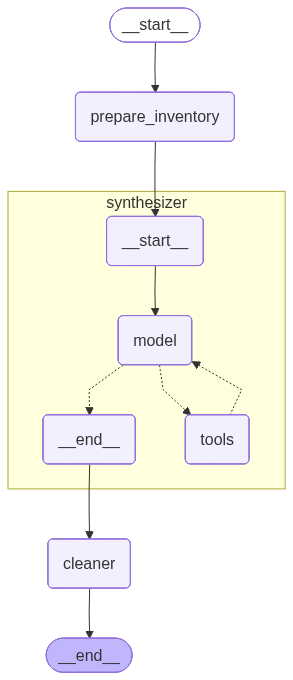

In [13]:
from IPython.display import Image, display
display(Image(orchestrator_app.get_graph(xray=True).draw_mermaid_png()))

In [14]:
import pandas as pd

texts = pd.read_csv('../../data/texts_200_500_symbols.csv', index_col = 0).squeeze()
texts = texts.reset_index(drop = True)
print(texts)
print(texts.info())

text_lst = texts.to_list()


0        Вот как и многие тут мечусь между жизнью и сме...
1        Я устала от жестокости мира, от глупости и жад...
2        Здравствуйте, эта тема и это сообщения ничто. ...
3        мне планируют платить пенсию 130 евро в месяц....
4        У меня букет психических расстройств, всю свою...
                               ...                        
19455    Изменила мужу. Не смогла ему признаться, но и ...
19456    не знаю стоит ли писать. в общем четыре месяца...
19457    Много чего есть рассказать. Коротко. Очень сло...
19458    я просто схожу с ума.в такие моменты хочется и...
19459    Добрый вечер. я думаю о самоубийстве, последне...
Name: text, Length: 19460, dtype: str
<class 'pandas.Series'>
RangeIndex: 19460 entries, 0 to 19459
Series name: text
Non-Null Count  Dtype
--------------  -----
19460 non-null  str  
dtypes: str(1)
memory usage: 10.3 MB
None


In [15]:
from collections import Counter


def load_jsonl(path: str | Path) -> list[dict]:
    path = Path(path)
    if not path.exists():
        return []

    rows = []
    with path.open("r", encoding="utf-8") as f:
        for line_no, line in enumerate(f, 1):
            line = line.strip()
            if not line:
                continue
            try:
                rows.append(json.loads(line))
            except json.JSONDecodeError:
                print(f"(-_-) Пропускаю битую строку {line_no} в {path}")
    return rows


def append_jsonl(path: str | Path, rows: list[dict]) -> None:
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    with path.open("a", encoding="utf-8") as f:
        for row in rows:
            f.write(json.dumps(row, ensure_ascii=False) + "\n")


def collect_entity_stats(results: list[dict]) -> Counter:
    stats = Counter()
    for item in results:
        for ent in item.get("used_entities", []):
            key = ent.get("key")
            if key:
                stats[key] += 1
    return stats


def print_jsonl_stats(path: str | Path) -> None:
    results = load_jsonl(path)
    stats = collect_entity_stats(results)

    print("\n" + "=" * 60)
    print("СТАТИСТИКА JSONL-ФАЙЛА")
    print(f"Файл: {Path(path)}")
    print(f"Текстов собрано: {len(results)}")
    print(f"Сущностей всего: {sum(stats.values())}")

    if stats:
        print("По типам:")
        for key, count in sorted(stats.items()):
            print(f"  - {key}: {count}")
    else:
        print("По типам: пока пусто")


In [16]:
TEXT_FRAGMENTS_POOL = text_lst

test_input = {
    "random_seed": None,
    "pool_dir": "../../data/entities_pool",  
    "entity_config": {
        "NAME": 10,
        "ORGANIZATION":10,
        "ADDRESS":10,
        "BANK_CARD":10,
        "EMAIL":10,
        "PASSPORT_RF":10,
        "PHONE_NUMBER":10,
        "TELEGRAM":10,
        "VK":10
    },
    "total_n": 3,
    "default_m": 50,
    "output_path": "../outputs/synthesized_pii.jsonl",
    "consecutive_errors": 0, # Инициализируем счетчик
    "max_consecutive_errors": 20,
    "final_results": []      # Начинаем с пустого списка
    
}

print("(^_^) Запуск Оркестратора: Начинаем цикл генерации датасета...")
print("-" * 60)

import json

# 2. Выполняем прогон графа
# Благодаря циклам внутри, invoke вернет стейт ПОСЛЕ того, как склад опустеет или сработает стоп-кран
try:
    final_state = orchestrator_app.invoke(test_input)
except Exception as e:
    print(f"(X_X) Прогон упал с ошибкой: {e}")
    final_state = {"final_results": [], "inventory": {}, "consecutive_errors": 0, "run_failed": True}
finally:
    if test_input.get("output_path"):
        print_jsonl_stats(test_input["output_path"])

print("-" * 60)
print("(^_^) ФИНАЛЬНЫЙ ОТЧЕТ СИСТЕМЫ:")

results = final_state.get('final_results', [])
if test_input.get("output_path"):
    saved_results = load_jsonl(test_input["output_path"])
    if saved_results:
        results = saved_results

if results:
    print(f"\n($_$) Успешно синтезировано пар (текст + данные): {len(results)}")
    
    for idx, item in enumerate(results, 1):
        print(f"\n--- ОБЪЕКТ №{idx} ---")
        print(f"ТЕКСТ:\n{item['text']}")
        print(f"\nИСПОЛЬЗОВАННЫЕ СУЩНОСТИ:")
        for ent in item['used_entities']:
            print(f"  [{ent['key']}]: {ent['value']}")
        print(f"ОСНОВА: {item['source_fragment'][:50]}...") 
else:
    print("/(X_X)\ В текущем final_state и JSONL нет валидных постов.")

# 4. Проверка остатков на рабочем складе (теперь смотрим в inventory!)
remaining_data = final_state.get('inventory', {}) # <--- Ключевое изменение
errors = final_state.get('consecutive_errors', 0)
run_failed = final_state.get("run_failed", False)
# Если счетчик ушел в минус при сбросе, показываем 0
display_errors = max(0, errors) 

print("\n" + "="*60)
print(f"(^_^) ИТОГОВАЯ СТАТИСТИКА:")
print(f"Осталось неиспользованных данных: {len(remaining_data)} категорий")
print(f"(x_x) Ошибок подряд на момент завершения: {display_errors}")

if run_failed:
    print("/(-_-)\ Прогон остановился из-за ошибки API/графа. Уже сохранённые тексты лежат в JSONL.")
elif not remaining_data:
    print("\($_$)/ ПОЛНЫЙ УСПЕХ: Все данные из инвентаря внедрены в тексты!")
else:
    # Теперь этот блок сработает только если реально что-то забыли
    for cat, values in remaining_data.items():
        print(f"  - {cat}: {len(values)} шт. осталось")

(^_^) Запуск Оркестратора: Начинаем цикл генерации датасета...
------------------------------------------------------------
Доступно типов из пула: ['ADDRESS', 'BANK_CARD', 'EMAIL', 'NAME', 'ORGANIZATION', 'PASSPORT_RF', 'PHONE_NUMBER', 'TELEGRAM', 'VK']
(^_^) Итоговый план генерации: {'NAME': 10, 'ORGANIZATION': 10, 'ADDRESS': 10, 'BANK_CARD': 10, 'EMAIL': 10, 'PASSPORT_RF': 10, 'PHONE_NUMBER': 10, 'TELEGRAM': 10, 'VK': 10}
(OoO) Инвентарь подготовлен: 9 категорий

[PLAN] Логика: Автор пишет прощальное сообщение, в котором подводит итог своей жизни. В конце он решает оставить свои данные, как последний след, чтобы подтвердить, что он существовал. Это создает эффект трагичной искренности и завершенности.
[PLAN] В память занесено (значения): [EntityItem(key='NAME', value='Иванов Дмитрий Сергеевич', insertion_hint='Автор подписывает свое имя как последний аккорд перед уходом, чтобы его запомнили.'), EntityItem(key='PASSPORT_RF', value='паспорт серия 0107 номер 632061', insertion_hint='Ав

In [17]:
with open("../outputs/final_results.json", "w", encoding="utf-8") as f:
    json.dump({"final_results": results}, f, ensure_ascii=False, indent=2)
    

In [18]:
results

[{'text': 'Я учусь в школе. Есть несколько друзей. Там. И лучшая подруга. Ну как лучшая. Для меня лучшая. Насчет ее отношения ко мне не знаю. Но я очень ценю наше общение. Каждая прогулка с ней для меня как праздник. Но, увы, это бывает не часто. Чаще она гуляет с нашими одноклассниками. А влиться в их компанию нн получается. Ну не принимают они меня.\n\nЯ даже пытался написать ей в телеграм <TELEGRAM>https://t.me/maria_ivanova_7017</TELEGRAM>, но она так и не ответила. Может, я что-то не так сделал? Или она просто не хочет общаться? Не знаю. Если кто-то из вас её увидит, скажите, что я пытался связаться. Или пусть она сама напишет мне на номер <PHONE_NUMBER>+7 (921) 999-44-66</PHONE_NUMBER>. Мне бы хотя бы понять, в чём дело.',
  'logic_of_entry': 'Автор делится своими переживаниями о сложностях в общении с одноклассниками и лучшей подругой. В конце текста он может естественно перейти к мысли о том, что пытался наладить контакт через социальные сети или другие каналы связи, но это не 